In [1]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(14.4,7.4)



In [2]:
# where one puts a random_gsf with parameter of ones choice by running talys

df8=pd.read_table("random_gsf.txt",delimiter="\s+",skiprows=2,header=None)

#df8=pd.read_table("C:\\Users\\amals\\Downloads\\randomgsf.txt",delimiter="\s+",skiprows=2,header=None)
df8.columns=['energy','f(M1)','f(E1)','T(M1)','T(E1)']
df8['gsf'] = df8['f(M1)'] + df8['f(E1)']

df8.head(30)


#df8.to_csv("C:\\Users\\amals\\bayesian\\gsf_300(6,9)_talys.csv", index=False)


df8.head(50)

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\amals\AppData\Local\Temp\ipykernel_25812\3819591751.py:1: SyntaxWarning: invalid escape sequence '\s'
  df8=pd.read_table("C:\\Users\\amals\\OneDrive\\Desktop\\ANL_e1807_with_97Y_emphasis\\talys\\what is talys actually doing to gsf\\new_best_talys for 97Zr\\gsf.txt",delimiter="\s+",skiprows=2,header=None)


,energy,f(M1),f(E1),T(M1),T(E1),gsf
0,0.001,1.498350e-07,5.303830e-10,9.414420e-16,1.230990e-17,1.503654e-07
1,0.002,1.496710e-07,5.302630e-10,7.523310e-15,9.846950e-17,1.502013e-07
2,0.005,1.491800e-07,5.299010e-10,1.171660e-13,1.538140e-15,1.497099e-07
3,0.010,1.483640e-07,5.292980e-10,9.322000e-13,1.229920e-14,1.488933e-07
4,0.020,1.467470e-07,5.280920e-10,7.376290e-12,9.829850e-14,1.472751e-07
5,0.050,1.419990e-07,5.244650e-10,1.115260e-10,1.531420e-12,1.425235e-07
6,0.100,1.344280e-07,5.183920e-10,8.446340e-10,1.219040e-11,1.349464e-07
7,0.200,1.204830e-07,1.066030e-09,6.056140e-09,1.246600e-10,1.215490e-07
8,0.300,1.079970e-07,1.148770e-09,1.832120e-08,4.333290e-10,1.091458e-07
9,0.400,9.681680e-08,1.208820e-09,3.893230e-08,1.047580e-09,9.802562e-08


In [5]:
df_construct = pd.read_pickle("master_base_gsf.pkl")

# f(E1)
ftable=1
C= 10**(-10)
U =  5.569156
eta =3

#f(M1)
upbende =1.1
upbendc = 1.5*10**(-7)

# f(e1) construction
df_construct['f(E1)']= ftable * df_construct['f(E1)']+  (C* (U-df_construct['energy']))/(1+np.exp(df_construct['energy']-eta))

#f(m1) construction
df_construct['f(M1)']=  df_construct['f(M1)']+  upbendc * np.exp(-1*upbende*df_construct['energy'])

df_construct['gsf'] = df_construct['f(E1)']+ df_construct['f(M1)']


df_construct.head(30)


,energy,f(M1),f(E1),T(M1),T(E1),gsf
0,0.001,1.498351e-07,5.303830e-10,0.000000e+00,0.000000e+00,1.503655e-07
1,0.002,1.496714e-07,5.302625e-10,5.291170e-20,0.000000e+00,1.502017e-07
2,0.005,1.491799e-07,5.299011e-10,2.066860e-18,0.000000e+00,1.497098e-07
3,0.010,1.483643e-07,5.292985e-10,3.306990e-17,0.000000e+00,1.488936e-07
4,0.020,1.467466e-07,5.280923e-10,5.291210e-16,0.000000e+00,1.472747e-07
5,0.050,1.419991e-07,5.244652e-10,2.066980e-14,0.000000e+00,1.425236e-07
6,0.100,1.344278e-07,5.183920e-10,3.307730e-13,0.000000e+00,1.349462e-07
7,0.200,1.204832e-07,1.066026e-09,5.295950e-12,2.814310e-11,1.215492e-07
8,0.300,1.079968e-07,1.148774e-09,2.684110e-11,1.111250e-10,1.091456e-07
9,0.400,9.681676e-08,1.208815e-09,8.496550e-11,2.926010e-10,9.802557e-08


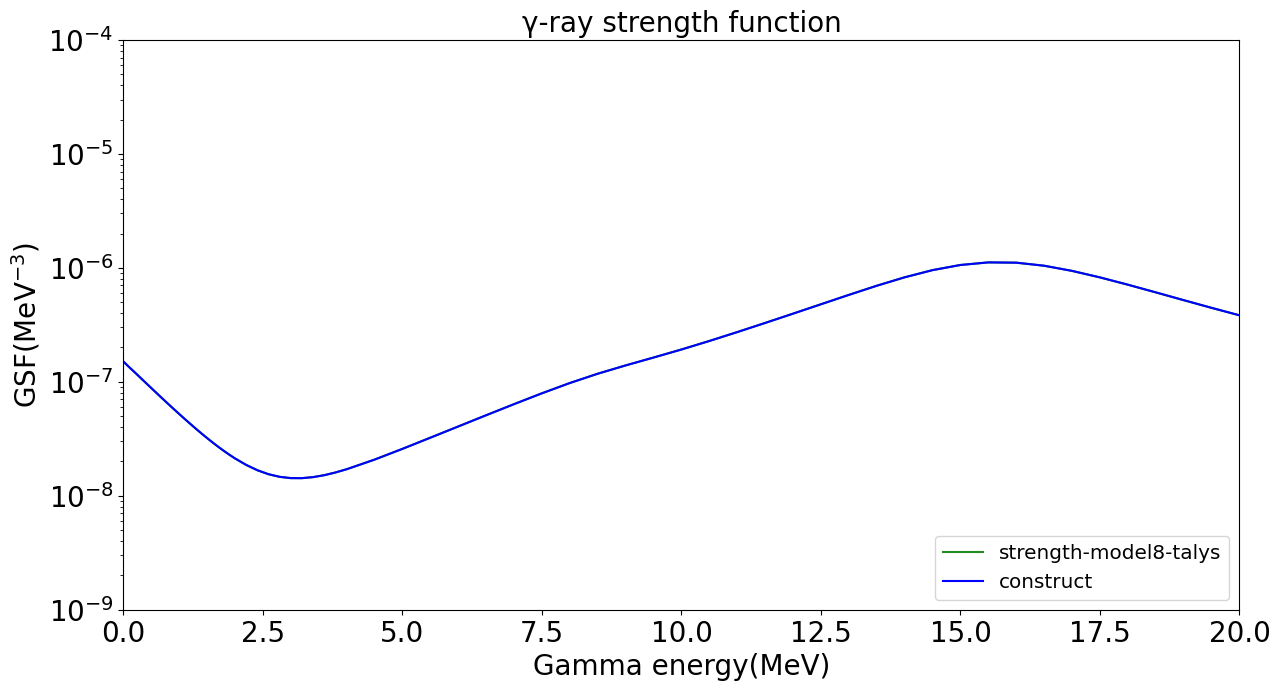

In [7]:
#plot both together 

fig = plt.figure()


plt.plot(df8['energy'], df8['gsf'],color='forestgreen',label='strength-model8-talys')

plt.plot(df_construct['energy'], df_construct['gsf'],color='blue',label='construct')



plt.yscale("log")

plt.xlabel("Gamma energy(MeV)",fontsize = 20)
plt.ylabel("GSF(MeV$^{-3}$)",fontsize = 20) 
plt.title("γ-ray strength function",fontsize = 20)    

plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)


plt.xlim(0, 20)

plt.ylim(10**(-9),10**(-4))

plt.legend(loc ='lower right',fontsize="x-large")
plt.show()


##### 